In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# -----------------------------
# 1. LOAD  ATLANTA DATA
# -----------------------------

# Air quality datasets
allAQI= pd.read_csv('ALL_AQI_2000_2025.csv')
CO=pd.read_csv('CO_2000_2025.csv')
no2=pd.read_csv('no2_2000_2025.csv')
ozone=pd.read_csv('ozone_2000_2025.csv')

# Preview (optional, for checking structure)
print("CO DATA RESULTS:\n ", CO.head())
print("\n-----------------------------\n")
print("NO2 DATA RESULTS: \n" ,no2.head())
print("\n-----------------------------\n")
print("OZONE DATA RESULTS: \n", ozone.head())
print("\n-----------------------------\n")



CO DATA RESULTS:
           Date  Carbon Monoxide AQI Value  Main Pollutant  \
0  01/01/2000                         34             NaN   
1  01/02/2000                         14             NaN   
2  01/03/2000                         20             NaN   
3  01/04/2000                          8             NaN   
4  01/05/2000                         24             NaN   

                                           Site Name      Site ID Source  
0                                      Not Available  13-089-1002    AQS  
1                                      Not Available  13-089-1002    AQS  
2  MONITOR LOCATED WITHIN PORTABLE INSTRUMENT SHE...  13-121-0099    AQS  
3  MONITOR LOCATED WITHIN PORTABLE INSTRUMENT SHE...  13-121-0099    AQS  
4  MONITOR LOCATED WITHIN PORTABLE INSTRUMENT SHE...  13-121-0099    AQS  

-----------------------------

NO2 DATA RESULTS: 
          Date Source    Site ID  POC  Daily Max 8-hour Ozone Concentration  \
0  03/01/1990    AQS  130850001    2    

In [8]:
# -----------------------------
# 2. TEMPERATURE DATA
# -----------------------------

# Manually created temperature dataset

tempData = [
    [2025, 7, 75.0, 55.7],
    [2024, 1, 75.8, 56.9],
    [2023, 4, 75.2, 56.6],
    [2022, 11, 74.1, 55.2],
    [2021, 10, 73.7, 55.6],
    [2020, 9, 73.9, 55.9],
    [2019, 2, 75.5, 56.9],
    [2018, 14, 73.4, 55.5],
    [2017, 6, 74.5, 56.3],
    [2016, 3, 75.9, 56.0],
    [2015, 12, 73.5, 55.7],
    [2014, 54, 72.1, 52.5],
    [2013, 57, 71.1, 53.4],
    [2012, 5, 75.4, 56.0],
    [2011, 15, 74.3, 54.2],
    [2010, 42, 72.3, 52.9],
    [2009, 60, 71.0, 53.2],
    [2008, 44, 72.2, 52.9],
    [2007, 13, 74.3, 54.7],
    [2006, 19, 73.1, 53.8],
    [2005, 53, 71.5, 53.2],
    [2004, 37, 71.7, 53.9],
    [2003, 67, 70.8, 52.8],
    [2002, 36, 72.1, 53.6],
    [2001, 43, 72.1, 53.0],
    [2000, 58, 72.0, 52.4]
]
#convert to DataFrame
tempDataDf = pd.DataFrame(tempData, columns=["Year", "Rank", "High", "Low"])

#Create avg temp column
tempDataDf['Avg_Temp'] = (tempDataDf['High']+tempDataDf['Low'])/2
print(tempDataDf)


    Year  Rank  High   Low  Avg_Temp
0   2025     7  75.0  55.7     65.35
1   2024     1  75.8  56.9     66.35
2   2023     4  75.2  56.6     65.90
3   2022    11  74.1  55.2     64.65
4   2021    10  73.7  55.6     64.65
5   2020     9  73.9  55.9     64.90
6   2019     2  75.5  56.9     66.20
7   2018    14  73.4  55.5     64.45
8   2017     6  74.5  56.3     65.40
9   2016     3  75.9  56.0     65.95
10  2015    12  73.5  55.7     64.60
11  2014    54  72.1  52.5     62.30
12  2013    57  71.1  53.4     62.25
13  2012     5  75.4  56.0     65.70
14  2011    15  74.3  54.2     64.25
15  2010    42  72.3  52.9     62.60
16  2009    60  71.0  53.2     62.10
17  2008    44  72.2  52.9     62.55
18  2007    13  74.3  54.7     64.50
19  2006    19  73.1  53.8     63.45
20  2005    53  71.5  53.2     62.35
21  2004    37  71.7  53.9     62.80
22  2003    67  70.8  52.8     61.80
23  2002    36  72.1  53.6     62.85
24  2001    43  72.1  53.0     62.55
25  2000    58  72.0  52.4     62.20


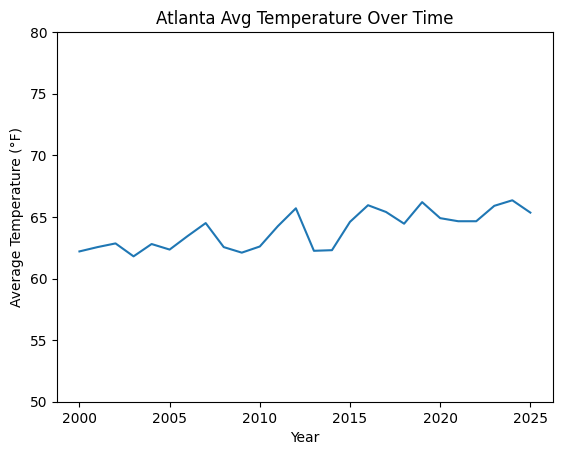

In [10]:
# -----------------------------
# 3. PLOT TEMPERATURE
# -----------------------------

plt.plot(tempDataDf["Year"], tempDataDf["Avg_Temp"])
plt.xlabel("Year")
plt.ylabel("Average Temperature (°F)")
plt.title("Atlanta Avg Temperature Over Time")
plt.ylim(50, 80)
plt.show()

In [29]:
#Convert date column to datetime
CO['Date'] = pd.to_datetime(CO['Date'])
#no2['Date'] = pd.to_datetime(no2['Date'])
ozone['Date'] = pd.to_datetime(ozone['Date'])
allAQI['Date'] =pd.to_datetime(allAQI['Date'])

#extract year
CO['Year'] = CO['Date'].dt.year
#no2['Year'] = no2['Date'].dt.year
ozone['Year'] = ozone['Date'].dt.year
allAQI['Year'] = allAQI['Date'].dt.year

#Compute yearly avg
CO_yearly = CO.groupby('Year')['Carbon Monoxide AQI Value'].mean().reset_index()
#no2_yearly = no2.groupby('Year')['Value'].mean().reset_index()
ozone_yearly = ozone.groupby('Year')['Ozone AQI Value'].mean().reset_index()
allAQI_yearly = allAQI.groupby('Year')['PM2.5 AQI Value'].mean().reset_index()


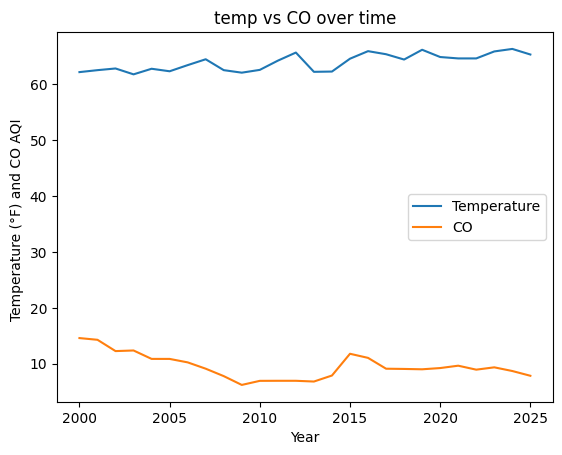

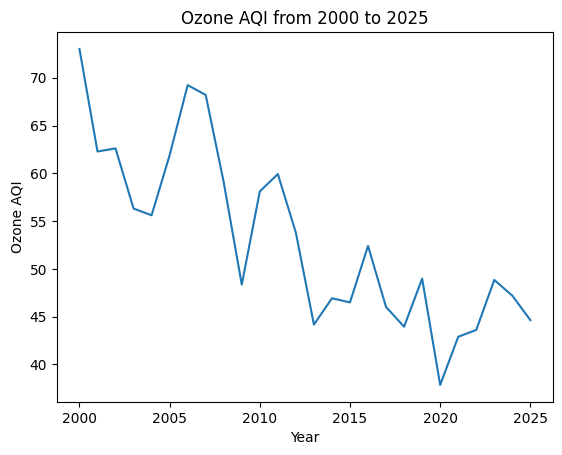

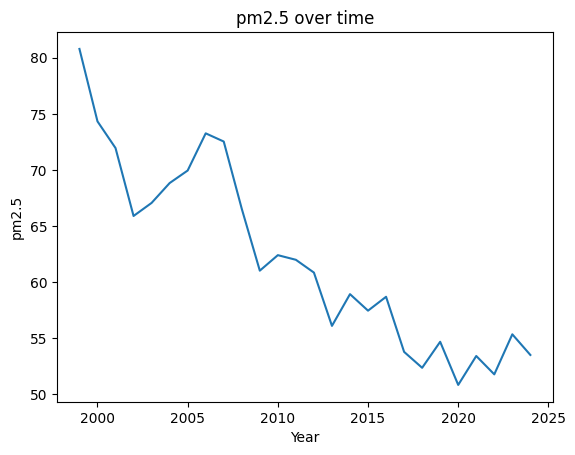

In [32]:
#Plot CO vs Temperature

plt.plot(tempDataDf["Year"], tempDataDf["Avg_Temp"], label = "Temperature")
plt.plot(CO_yearly["Year"], CO_yearly["Carbon Monoxide AQI Value"], label = "CO")

plt.xlabel("Year")
plt.ylabel("Temperature (°F) and CO AQI ")
plt.title("temp vs CO over time")
plt.legend()
plt.show()

#plot ozone 
plt.plot(ozone_yearly["Year"], ozone_yearly["Ozone AQI Value"], label = "Ozone")
plt.xlabel("Year")
plt.ylabel("Ozone AQI")
plt.title("Ozone AQI from 2000 to 2025")
plt.show()

#plot pm2.5 AQI
plt.plot(allAQI_yearly["Year"],allAQI_yearly["PM2.5 AQI Value"], label = "pm2.5 AQI")
plt.xlabel("Year")
plt.ylabel("pm2.5")
plt.title("pm2.5 over time")
plt.show()


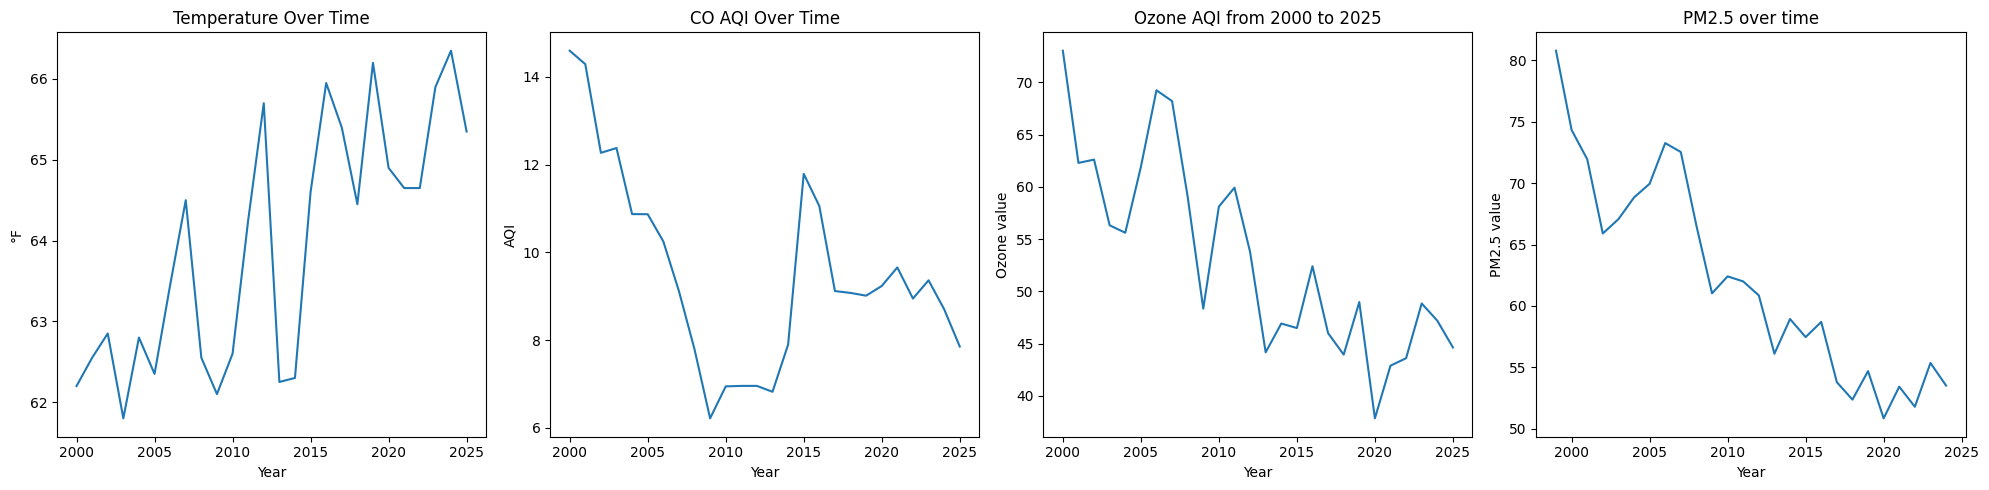

In [34]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20,5))

# Temperature graph
ax1.plot(tempDataDf["Year"], tempDataDf["Avg_Temp"])
ax1.set_title("Temperature Over Time")
ax1.set_xlabel("Year")
ax1.set_ylabel("°F")

# CO graph
ax2.plot(CO_yearly["Year"], CO_yearly["Carbon Monoxide AQI Value"])
ax2.set_title("CO AQI Over Time")
ax2.set_xlabel("Year")
ax2.set_ylabel("AQI")

#Ozone graph
ax3.plot(ozone_yearly["Year"], ozone_yearly["Ozone AQI Value"])
ax3.set_title("Ozone AQI from 2000 to 2025")
ax3.set_xlabel("Year")
ax3.set_ylabel("Ozone value")
#pm2.5 graph
ax4.plot(allAQI_yearly["Year"], allAQI_yearly["PM2.5 AQI Value"])
ax4.set_title("PM2.5 over time")
ax4.set_xlabel("Year")
ax4.set_ylabel("PM2.5 value")

plt.tight_layout()
plt.show()